In [12]:
%pip install scikit-learn
%pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 42.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 86.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import re
from Bio.PDB import PDBParser, is_aa
from Bio import pairwise2, PDB
from Bio.PDB import PDBIO
import requests
from Bio.pairwise2 import format_alignment
import Bio.Align
import numpy as np
#import numba
#from numba import jit
#from numba import njit
from multiprocessing import cpu_count
import time
import os
import shutil
import pickle
from sklearn.model_selection import train_test_split
import prody as pr
import json
# import pulp
from joblib import Parallel, delayed
import psutil
import concurrent.futures
import gc
import hashlib
import os
import gzip
from queue import Queue
from IPython.display import display, clear_output
from datetime import datetime, timedelta
import glob
import multiprocessing as mp
from multiprocessing import Pool, shared_memory
from functools import partial
import logging
from datetime import datetime
import math
import random
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
#try:
#    from tqdm.notebook import tqdm
#    JUPYTER = True
#except ImportError:
#    from tqdm import tqdm
#    JUPYTER = False
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings('ignore')



# PART 1: INITIAL SIZE & CLASS FILTRATION

In [31]:
# Function to parse the protein sequence file
def parse_protein_file(file_path):
    data = []
    current_entry = {}

    with open(file_path, 'r') as file:
        lines = file.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()

        # Check if this is a header line (starts with 'd' and contains protein info)
        if line and not line[0].islower() or line.startswith('d'):
            # Parse header line
            if 'd' in line and '{' in line:
                # Extract protein ID (first part before space)
                parts = line.split()
                protein_id = parts[0]

                # Extract classification (like a.1.1.1)
                classification = parts[1] if len(parts) > 1 else ""

                # Extract description and organism info
                desc_start = line.find('(A:)')
                if desc_start != -1:
                    desc_part = line[desc_start + 4:].strip()

                    # Split description and organism
                    if '{' in desc_part and '}' in desc_part:
                        description = desc_part[:desc_part.find('{')].strip()
                        organism_part = desc_part[desc_part.find('{')+1:desc_part.find('}')]
                    else:
                        description = desc_part
                        organism_part = ""
                else:
                    description = ""
                    organism_part = ""

                # Save previous entry if exists
                if current_entry:
                    data.append(current_entry)

                # Start new entry
                current_entry = {
                    'protein_id': protein_id,
                    'classification': classification,
                    'description': description,
                    'organism': organism_part,
                    'sequence': ""
                }
            i += 1
        else:
            # This is a sequence line
            if current_entry and line:
                current_entry['sequence'] += line
            i += 1

    # Add the last entry
    if current_entry:
        data.append(current_entry)

    return pd.DataFrame(data)

# Replace 'your_file_path' with the actual path to your file in Google Drive
# For example: '/content/drive/MyDrive/protein_sequences.txt'
file_path = '/home/okleinmann/upside2-ipy/condiv/SCOPe/astral.txt'

# Parse the file and create dataframe
astral = parse_protein_file(file_path)

astral['len'] = astral['sequence'].apply(len)
astral

,protein_id,classification,description,organism,sequence,len
0,>d1ux8a_,a.1.1.1,Protozoan/bacterial hemoglobin,Bacillus subtilis [TaxId: 1423],napyeaigeellsqlvdtfyervashpllkpifpsdltetarkqkq...,119
1,>d1dlwa_,a.1.1.1,Protozoan/bacterial hemoglobin,Ciliate (Paramecium caudatum) [TaxId: 5885],slfeqlggqaavqavtaqfyaniqadatvatffngidmpnqtnkta...,116
2,>d1dlya_,a.1.1.1,Protozoan/bacterial hemoglobin,Green alga (Chlamydomonas eugametos) [TaxId: 3...,slfaklggreaveaavdkfynkivadptvstyfsntdmkvqrskqf...,121
3,>d2gkma_,a.1.1.1,Protozoan/bacterial hemoglobin,"Mycobacterium tuberculosis, HbN [TaxId: 1773]",gllsrlrkrepisiydkiggheaievvvedffvrvladdqlsaffs...,127
4,>d1ngka_,a.1.1.1,Protozoan/bacterial hemoglobin,"Mycobacterium tuberculosis, HbO [TaxId: 1773]",ksfydavggaktfdaivsrfyaqvaedevlrrvypeddlagaeerl...,126
...,...,...,...,...,...,...
35489,>d5syba_,g.101.1.1,Pre-mRNA splicing factor Phf5 / Rds3,Human (Homo sapiens) [TaxId: 9606],akhhpdlifcrkqagvaigrlcekcdgkcvicdsyvrpstlvricd...,90
35490,>d5ifed_,g.101.1.1,,,sdayyckectiqekdrdgcpkivnlgssk,29
35491,>d5fyza2,g.102.1.0,,,rycvfshdemickmaskadvldvvvastvqkdmaimiedekalret...,131
35492,>d5fwja2,g.102.1.0,,,rycvfsheelickmaacpekldlnlaaavhkemfimvqeerrlrka...,132


In [32]:
alphas = astral[astral['classification'].str.startswith('a')]
alphas

,protein_id,classification,description,organism,sequence,len
0,>d1ux8a_,a.1.1.1,Protozoan/bacterial hemoglobin,Bacillus subtilis [TaxId: 1423],napyeaigeellsqlvdtfyervashpllkpifpsdltetarkqkq...,119
1,>d1dlwa_,a.1.1.1,Protozoan/bacterial hemoglobin,Ciliate (Paramecium caudatum) [TaxId: 5885],slfeqlggqaavqavtaqfyaniqadatvatffngidmpnqtnkta...,116
2,>d1dlya_,a.1.1.1,Protozoan/bacterial hemoglobin,Green alga (Chlamydomonas eugametos) [TaxId: 3...,slfaklggreaveaavdkfynkivadptvstyfsntdmkvqrskqf...,121
3,>d2gkma_,a.1.1.1,Protozoan/bacterial hemoglobin,"Mycobacterium tuberculosis, HbN [TaxId: 1773]",gllsrlrkrepisiydkiggheaievvvedffvrvladdqlsaffs...,127
4,>d1ngka_,a.1.1.1,Protozoan/bacterial hemoglobin,"Mycobacterium tuberculosis, HbO [TaxId: 1773]",ksfydavggaktfdaivsrfyaqvaedevlrrvypeddlagaeerl...,126
...,...,...,...,...,...,...
5438,>d3r3la1,a.300.1.1,,,ksflwtqslrrelsgycsniklqvvkdaqallhgldfsevsnvqrl...,331
5439,>d4dhxb_,a.301.1.1,,,aeitpkgralvpdsvkkellqrirtflaqha,31
5440,>d3mhsb_,a.301.1.1,,,taqlksqiqqylvesgnyelisnelkarllqegwvdkvkdltksem...,91
5441,>d3kjlc_,a.301.1.1,,,qqylvesgnyelisnelkarllqegwvdkvkdltksemninestnf...,80


In [33]:
runnable_alphas = alphas[(alphas['len'] <= 300) & (alphas['len'] >= 20)]
runnable_alphas

,protein_id,classification,description,organism,sequence,len
0,>d1ux8a_,a.1.1.1,Protozoan/bacterial hemoglobin,Bacillus subtilis [TaxId: 1423],napyeaigeellsqlvdtfyervashpllkpifpsdltetarkqkq...,119
1,>d1dlwa_,a.1.1.1,Protozoan/bacterial hemoglobin,Ciliate (Paramecium caudatum) [TaxId: 5885],slfeqlggqaavqavtaqfyaniqadatvatffngidmpnqtnkta...,116
2,>d1dlya_,a.1.1.1,Protozoan/bacterial hemoglobin,Green alga (Chlamydomonas eugametos) [TaxId: 3...,slfaklggreaveaavdkfynkivadptvstyfsntdmkvqrskqf...,121
3,>d2gkma_,a.1.1.1,Protozoan/bacterial hemoglobin,"Mycobacterium tuberculosis, HbN [TaxId: 1773]",gllsrlrkrepisiydkiggheaievvvedffvrvladdqlsaffs...,127
4,>d1ngka_,a.1.1.1,Protozoan/bacterial hemoglobin,"Mycobacterium tuberculosis, HbO [TaxId: 1773]",ksfydavggaktfdaivsrfyaqvaedevlrrvypeddlagaeerl...,126
...,...,...,...,...,...,...
5436,>d4j4xa_,a.299.1.1,automated matches,Granada virus [TaxId: 904668],vlnlvrgnkpesmmkkmsekgaaivtqlistyqlkegnpgrdtitl...,190
5439,>d4dhxb_,a.301.1.1,,,aeitpkgralvpdsvkkellqrirtflaqha,31
5440,>d3mhsb_,a.301.1.1,,,taqlksqiqqylvesgnyelisnelkarllqegwvdkvkdltksem...,91
5441,>d3kjlc_,a.301.1.1,,,qqylvesgnyelisnelkarllqegwvdkvkdltksemninestnf...,80


# PART 2: FINDING A DIVERSE TRAINING SET BY SEQUENCE SIMILARITY

In [34]:
sequences = list(runnable_alphas['sequence'])
sequences[0:7]


['napyeaigeellsqlvdtfyervashpllkpifpsdltetarkqkqfltqylggpplyteehghpmlrarhlpfpitneradawlscmkdamdhvglegeireflfgrleltarhmvnq',
 'slfeqlggqaavqavtaqfyaniqadatvatffngidmpnqtnktaaflcaalggpnawtgrnlkevhanmgvsnaqfttvighlrsaltgagvaaalveqtvavaetvrgdvvtv',
 'slfaklggreaveaavdkfynkivadptvstyfsntdmkvqrskqfaflayalggasewkgkdmrtahkdlvphlsdvhfqavarhlsdtltelgvppeditdamavvastrtevlnmpqq',
 'gllsrlrkrepisiydkiggheaievvvedffvrvladdqlsaffsgtnmsrlkgkqveffaaalggpepytgapmkqvhqgrgitmhhfslvaghladaltaagvpsetiteilgviaplavdvts',
 'ksfydavggaktfdaivsrfyaqvaedevlrrvypeddlagaeerlrmfleqywggprtyseqrghprlrmrhapfrislierdawlrcmhtavasidsetlddehrrelldylemaahslvnspf',
 'stlyeklggttavdlavdkfyervlqddrikhffadvdmakqrahqkafltyafggtdkylnq',
 'kqpmtpfeaiggeqcieilvdtfysyvskhpdlspifpddltetarkqkqfltqylggpnlyteehghpmlrarhlpfeitpkraeawlscmeqamddtgvhghirefvferlaltaqhmvntpnetgei']

In [35]:
def batch_similarity(seqs1, seqs2, aligner):
    """Fast batch computation of sequence similarities using BioPython aligner"""
    similarities = np.zeros(len(seqs1))
    for i in range(len(seqs1)):
        seq1, seq2 = seqs1[i], seqs2[i]
        score = aligner.score(seq1, seq2)
        max_len = max(len(seq1), len(seq2))
        max_possible_score = max_len * aligner.match_score
        similarities[i] = score / max_possible_score
    return similarities

def compute_block(sequences, i_start, i_end, j_start, j_end, aligner):
    """Compute similarities for one block of the matrix"""
    pairs = []
    positions = []

    for i in range(i_start, i_end):
        for j in range(j_start, j_end):
            pairs.append((sequences[i], sequences[j]))
            positions.append((i, j))

    if pairs:
        seqs1, seqs2 = zip(*pairs)
        similarities = batch_similarity(list(seqs1), list(seqs2), aligner)
        return list(zip(positions, similarities))
    return []

def save_progress(matrix, completed_blocks, cache_dir):
    """Save current progress to cache"""
    os.makedirs(cache_dir, exist_ok=True)

    # Save matrix state
    np.save(os.path.join(cache_dir, "matrix_current.npy"), matrix)

    # Save completed blocks list
    with open(os.path.join(cache_dir, "completed_blocks.json"), "w") as f:
        json.dump(completed_blocks, f)

    print(f"Progress saved: {len(completed_blocks)} blocks completed")

def load_progress(cache_dir, matrix_shape):
    """Load previous progress from cache"""
    matrix_file = os.path.join(cache_dir, "matrix_current.npy")
    blocks_file = os.path.join(cache_dir, "completed_blocks.json")

    if os.path.exists(matrix_file) and os.path.exists(blocks_file):
        matrix = np.load(matrix_file)
        with open(blocks_file, "r") as f:
            completed_blocks = set(map(tuple, json.load(f)))

        print(f"Resuming from cache: {len(completed_blocks)} blocks already completed")
        return matrix, completed_blocks
    else:
        print("No previous progress found, starting fresh")
        return np.zeros(matrix_shape), set()

def format_time(seconds):
    """Format seconds into human readable time"""
    if seconds < 60:
        return f"{seconds:.1f} seconds"
    elif seconds < 3600:
        minutes = seconds / 60
        return f"{minutes:.1f} minutes"
    else:
        hours = seconds / 3600
        return f"{hours:.1f} hours"

def create_similarity_matrix(sequences, block_size=50, cache_dir="similarity_cache", save_every=20):
    """Create symmetric pairwise similarity matrix with caching for resumability"""
    n = len(sequences)

    # Create aligner once
    aligner = Bio.Align.PairwiseAligner()

    # Generate all blocks
    all_blocks = []
    for i in range(0, n, block_size):
        for j in range(i, n, block_size):
            block = (i, min(i + block_size, n), j, min(j + block_size, n))
            all_blocks.append(block)

    # Load previous progress
    matrix, completed_blocks = load_progress(cache_dir, (n, n))

    # Filter out already completed blocks
    remaining_blocks = [block for block in all_blocks
                       if (block[0], block[1], block[2], block[3]) not in completed_blocks]

    print(f"Total blocks: {len(all_blocks)}")
    print(f"Remaining blocks: {len(remaining_blocks)}")
    print(f"Using BioPython alignment with {cpu_count()} CPU cores")

    if not remaining_blocks:
        print("All blocks already completed!")
        return matrix

    # Track timing for estimation
    start_time = time.time()
    initial_completed = len(completed_blocks)

    # Process remaining blocks in parallel
    with ProcessPoolExecutor(max_workers=cpu_count()) as executor:
        # Submit all remaining blocks
        future_to_block = {
            executor.submit(compute_block, sequences, i_start, i_end, j_start, j_end, aligner):
            (i_start, i_end, j_start, j_end)
            for i_start, i_end, j_start, j_end in remaining_blocks
        }

        completed_count = len(completed_blocks)

        for future in future_to_block:
            try:
                results = future.result()
                block = future_to_block[future]

                # Update matrix
                for (i, j), similarity in results:
                    matrix[i, j] = similarity
                    if i != j:
                        matrix[j, i] = similarity

                # Mark block as completed
                completed_blocks.add(block)
                completed_count += 1

                # Save progress periodically
                if completed_count % save_every == 0:
                    save_progress(matrix, list(completed_blocks), cache_dir)

                # Progress reporting with time estimation every 100 blocks
                if completed_count % 100 == 0:
                    elapsed_time = time.time() - start_time
                    blocks_processed_this_session = completed_count - initial_completed

                    if blocks_processed_this_session > 0:
                        avg_time_per_block = elapsed_time / blocks_processed_this_session
                        remaining_blocks_count = len(all_blocks) - completed_count
                        estimated_remaining_time = remaining_blocks_count * avg_time_per_block

                        print(f"Completed {completed_count}/{len(all_blocks)} blocks...")
                        print(f"Estimated time to completion: {format_time(estimated_remaining_time)}")
                        print(f"Average time per block: {avg_time_per_block:.2f} seconds")
                    else:
                        print(f"Completed {completed_count}/{len(all_blocks)} blocks...")

            except Exception as e:
                print(f"Error processing block {future_to_block[future]}: {e}")

    # Final save
    save_progress(matrix, list(completed_blocks), cache_dir)

    # Save final result
    np.save(os.path.join(cache_dir, "final_matrix.npy"), matrix)
    print(f"Final matrix saved to {cache_dir}/final_matrix.npy")

    total_time = time.time() - start_time
    print(f"Total processing time: {format_time(total_time)}")

    return matrix

def cleanup_cache(cache_dir):
    """Clean up cache files after successful completion"""
    files_to_remove = [
        "matrix_current.npy",
        "completed_blocks.json"
    ]

    for filename in files_to_remove:
        filepath = os.path.join(cache_dir, filename)
        if os.path.exists(filepath):
            os.remove(filepath)

    print(f"Cache cleaned up. Final result remains in {cache_dir}/final_matrix.npy")

def validate_sequences(sequences):
    """Check for and report problematic sequences"""
    issues = []

    for i, seq in enumerate(sequences):
        if len(seq) == 0:
            issues.append(f"Sequence {i}: Empty sequence")
        elif not isinstance(seq, str):
            issues.append(f"Sequence {i}: Not a string (type: {type(seq)})")
        elif not seq.replace('-', '').replace('N', ''):  # Only gaps and Ns
            issues.append(f"Sequence {i}: Only contains gaps/Ns")

    if issues:
        print(f"Found {len(issues)} problematic sequences:")
        for issue in issues[:10]:  # Show first 10
            print(f"  {issue}")
        if len(issues) > 10:
            print(f"  ... and {len(issues) - 10} more")
        else:
            print("No problematic sequences found.")

In [8]:
#ensure only valid sequences
validate_sequences(sequences)

# First run (or resuming from interruption)
matrix = create_similarity_matrix(
    sequences,
    block_size=50,
    cache_dir="SCOPe/similarity_cache",  # Where to save progress
    save_every=20  # Save progress every 20 blocks
)

# If interrupted, just run the same command again - it will resume!

# After completion, clean up intermediate files
cleanup_cache("similarity_cache")

Resuming from cache: 4753 blocks already completed
Total blocks: 4753
Remaining blocks: 0
Using BioPython alignment with 48 CPU cores
All blocks already completed!
Cache cleaned up. Final result remains in similarity_cache/final_matrix.npy


In [49]:
similarity_matrix = np.load("SCOPe/similarity_cache/final_matrix.npy")
similarity_df = pd.DataFrame(similarity_matrix,index=sequences,columns=sequences)
similarity_df

,napyeaigeellsqlvdtfyervashpllkpifpsdltetarkqkqfltqylggpplyteehghpmlrarhlpfpitneradawlscmkdamdhvglegeireflfgrleltarhmvnq,slfeqlggqaavqavtaqfyaniqadatvatffngidmpnqtnktaaflcaalggpnawtgrnlkevhanmgvsnaqfttvighlrsaltgagvaaalveqtvavaetvrgdvvtv,slfaklggreaveaavdkfynkivadptvstyfsntdmkvqrskqfaflayalggasewkgkdmrtahkdlvphlsdvhfqavarhlsdtltelgvppeditdamavvastrtevlnmpqq,gllsrlrkrepisiydkiggheaievvvedffvrvladdqlsaffsgtnmsrlkgkqveffaaalggpepytgapmkqvhqgrgitmhhfslvaghladaltaagvpsetiteilgviaplavdvts,ksfydavggaktfdaivsrfyaqvaedevlrrvypeddlagaeerlrmfleqywggprtyseqrghprlrmrhapfrislierdawlrcmhtavasidsetlddehrrelldylemaahslvnspf,stlyeklggttavdlavdkfyervlqddrikhffadvdmakqrahqkafltyafggtdkylnq,kqpmtpfeaiggeqcieilvdtfysyvskhpdlspifpddltetarkqkqfltqylggpnlyteehghpmlrarhlpfeitpkraeawlscmeqamddtgvhghirefvferlaltaqhmvntpnetgei,eqwqtlyeaiggeetvaklveafyrrvaahpdlrpifpddltetahkqkqfltqylggpplytaehghpmlrarhlrfeitpkraeawlacmraamdeiglsgpareqfyhrlvltahhmvntpdhld,aslyeklggaaavdlavekfygkvladervnrffvntdmakqkqhqkdfmtyafggtdrfpgrsmraahqdlvenagltdvhfdaiaenlvltlqelnvsqdlidevvtivgsvqhrndvlnr,mtfyeavggeetftrlarrfyegvaadpvlrpmypeedlgpaeerlrlflmqywggprtyserrghprlrmrhfpyrigaeerdrwlthmraavddlalpahleqqlweylvyaayamvnvpe,...,seswynllldmqnrlnkviksvgkiehsfwrsfhterktepatgfidgdliesfldisrpkmqevvanlqyddgsgmkreataddlikvveeltrih,eqvvaiasniggkqaletvqrllpvlcqahgltpeqvvaiashdggkqale,mdnyqelrvqfaaqavdrneieqwvrefayqgfdarrviellkqyggadwekdakkmivlaltrgnkprrmmmkmskegkatvealinkyklkegnpsrdeltlsrvaaalagwtcqalvvlsewlpvtgttmdglspayprhmmhpsfagmvdpslpgdylraildahslyllqfsrvinpnlrgrtkeevaatftqpmnaavnsnfishekrreflkafglvdsngkpsaavmaaaqayktaa,msyeeiaiqfasesvdattiaawvsefayqgfdarqvinlvkqrggddwkedvkkmivlsltrgnkpskmlnkmsesgqkivndliskyklksgnpgrndltlsriaaafagwtcqaaevvqdylpvtgramdaisdkfpralmhpsfaglvdptlpegvvedivhahclfmiqfsktinpslrsssksevvssfdrpmqaainspfltagnrrdilmslglinsnlkpsptvvaaakvyrkl,nyrdialafldesadsgtinawvnefayqgfdpkrivqlvkergtakgrdwkkdvkmmivlnlvrgnkpeammkkmsekgasivanlisvyqlkegnpgrdtitlsrvsaafvpwtvqalrvlseslpvsgttmdaiagvtyprammhpsfagiidldlpngagatiadahglfmiefsktinpslrtkqanevaatfekpnmaamsgrfftredkkklliavgiidedlvlasavvrsaekyr,vlnlvrgnkpesmmkkmsekgaaivtqlistyqlkegnpgrdtitlsrvsaafvpwtvqalktlseslpvtgttmdsiagttyprcmmhpsfagiidlelpnntgamladahglfmlefsktinpslrtkqpneiaatfekpnmaamtgrfftrddkkklliaigvlnedlvpnpaiekcaekykakvgk,aeitpkgralvpdsvkkellqrirtflaqha,taqlksqiqqylvesgnyelisnelkarllqegwvdkvkdltksemninestnftqilstvepkalemvsdstretvlkqirefleeivdt,qqylvesgnyelisnelkarllqegwvdkvkdltksemninestnftqilstvepkalemvsdstretvlkqirefleei,kllpgpnkmlpkvffskkwmayynpsediqkiykngtfkkgdmfnlndchklidffkdsisrypkwsnaydfnfsetekykdiagfyreveeqg
napyeaigeellsqlvdtfyervashpllkpifpsdltetarkqkqfltqylggpplyteehghpmlrarhlpfpitneradawlscmkdamdhvglegeireflfgrleltarhmvnq,1.000000,0.336134,0.404959,0.385827,0.436508,0.260504,0.684615,0.656250,0.365854,0.463415,...,0.336134,0.243697,0.248980,0.255144,0.241803,0.284211,0.176471,0.327731,0.310924,0.294118
slfeqlggqaavqavtaqfyaniqadatvatffngidmpnqtnktaaflcaalggpnawtgrnlkevhanmgvsnaqfttvighlrsaltgagvaaalveqtvavaetvrgdvvtv,0.336134,1.000000,0.487603,0.401575,0.349206,0.258621,0.346154,0.375000,0.422764,0.349593,...,0.301724,0.258621,0.261224,0.246914,0.250000,0.289474,0.146552,0.336207,0.293103,0.275862
slfaklggreaveaavdkfynkivadptvstyfsntdmkvqrskqfaflayalggasewkgkdmrtahkdlvphlsdvhfqavarhlsdtltelgvppeditdamavvastrtevlnmpqq,0.404959,0.487603,1.000000,0.433071,0.388889,0.305785,0.384615,0.398438,0.520325,0.373984,...,0.289256,0.231405,0.248980,0.251029,0.245902,0.278947,0.165289,0.314050,0.297521,0.305785
gllsrlrkrepisiydkiggheaievvvedffvrvladdqlsaffsgtnmsrlkgkqveffaaalggpepytgapmkqvhqgrgitmhhfslvaghladaltaagvpsetiteilgviaplavdvts,0.385827,0.401575,0.433071,1.000000,0.401575,0.267717,0.384615,0.398438,0.393701,0.362205,...,0.314961,0.228346,0.265306,0.246914,0.262295,0.289474,0.165354,0.307087,0.267717,0.267717
ksfydavggaktfdaivsrfyaqvaedevlrrvypeddlagaeerlrmfleqywggprtyseqrghprlrmrhapfrislierdawlrcmhtavasidsetlddehrrelldylemaahslvnspf,0.436508,0.349206,0.388889,0.401575,1.000000,0.238095,0.430769,0.453125,0.388889,0.

In [9]:
# Set up logging
def setup_logging():
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.StreamHandler(),
            logging.FileHandler('set_finder.log')
        ]
    )
    return logging.getLogger(__name__)

logger = setup_logging()

class HybridSetFinder:
    def __init__(self, matrix):
        self.matrix = matrix.astype(np.float32)
        self.n = matrix.shape[0]
        logger.info(f"Initialized with {self.n}×{self.n} matrix ({self.matrix.nbytes / 1024**2:.1f} MB)")
    
    @staticmethod
    @jit(nopython=True, fastmath=True)
    def compute_set_cost(indices, matrix):
        """Average pairwise interaction in set (lower is better)"""
        if len(indices) < 2:
            return 0.0
        
        total = 0.0
        count = 0
        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                total += matrix[indices[i], indices[j]]
                count += 1
        return total / count
    
    def greedy_construction_with_snapshots(self, target_sizes, start_node, attempt_id=0, progress_queue=None):
        """
        Greedy construction that captures snapshots at specified sizes
        """
        # Sort target sizes to process in order
        target_sizes = sorted(set(target_sizes))
        max_size = max(target_sizes)
        
        current_set = [start_node]
        used = np.zeros(self.n, dtype=bool)
        used[start_node] = True
        
        logger.info(f"Attempt {attempt_id}: Starting construction with targets={target_sizes}, start={start_node}")
        
        snapshots = {}
        target_idx = 0  # Index of next target size to capture
        completed_targets = []
        
        # Progress tracking
        last_update = time.time()
        update_interval = 3.0  # Update every 3 seconds
        
        for step in range(max_size - 1):
            best_cost = float('inf')
            best_candidate = -1
            
            # Test every unused candidate
            for candidate in range(self.n):
                if used[candidate]:
                    continue
                
                # Create test set
                test_set = current_set + [candidate]
                test_indices = np.array(test_set, dtype=np.int32)
                
                # Calculate full set cost
                cost = self.compute_set_cost(test_indices, self.matrix)
                
                if cost < best_cost:
                    best_cost = cost
                    best_candidate = candidate
            
            if best_candidate == -1:
                logger.warning(f"Attempt {attempt_id}: No more candidates at step {step+1}")
                break
            
            current_set.append(best_candidate)
            used[best_candidate] = True
            
            # Check if we've reached any target sizes
            current_size = len(current_set)
            while target_idx < len(target_sizes) and current_size >= target_sizes[target_idx]:
                target_size = target_sizes[target_idx]
                snapshot_set = np.array(current_set[:target_size], dtype=np.int32)
                snapshot_cost = self.compute_set_cost(snapshot_set, self.matrix)
                
                snapshots[target_size] = {
                    'set': snapshot_set.copy(),
                    'cost': snapshot_cost,
                    'step': step + 1,
                    'start_node': start_node
                }
                
                completed_targets.append(target_size)
                logger.info(f"Attempt {attempt_id}: Snapshot captured - size={target_size}, cost={snapshot_cost:.6f}")
                target_idx += 1
            
            # Periodic progress updates
            current_time = time.time()
            if current_time - last_update >= update_interval:
                if progress_queue:
                    progress_queue.put({
                        'attempt_id': attempt_id,
                        'current_size': current_size,
                        'max_size': max_size,
                        'cost': best_cost,
                        'completed_targets': completed_targets.copy(),
                        'status': 'running'
                    })
                last_update = current_time
        
        # Make sure we got all target sizes
        final_size = len(current_set)
        while target_idx < len(target_sizes):
            target_size = target_sizes[target_idx]
            if target_size <= final_size:
                snapshot_set = np.array(current_set[:target_size], dtype=np.int32)
                snapshot_cost = self.compute_set_cost(snapshot_set, self.matrix)
                
                snapshots[target_size] = {
                    'set': snapshot_set.copy(),
                    'cost': snapshot_cost,
                    'step': final_size,
                    'start_node': start_node
                }
                
                if target_size not in completed_targets:
                    completed_targets.append(target_size)
                
                logger.info(f"Attempt {attempt_id}: Final snapshot - size={target_size}, cost={snapshot_cost:.6f}")
            
            target_idx += 1
        
        # Final progress update
        if progress_queue:
            progress_queue.put({
                'attempt_id': attempt_id,
                'current_size': len(current_set),
                'max_size': max_size,
                'cost': 'DONE',
                'completed_targets': completed_targets.copy(),
                'status': 'completed'
            })
        
        logger.info(f"Attempt {attempt_id}: Construction complete - final size={len(current_set)}")
        return snapshots

def worker_thread(finder, start_node, attempt_id, target_sizes, progress_queue, results_queue):
    """Worker thread for running one construction"""
    try:
        start_time = time.time()
        snapshots = finder.greedy_construction_with_snapshots(
            target_sizes, start_node, attempt_id, progress_queue
        )
        elapsed = time.time() - start_time
        
        results_queue.put({
            'attempt_id': attempt_id,
            'snapshots': snapshots,
            'elapsed': elapsed,
            'success': True
        })
        
    except Exception as e:
        logger.error(f"Attempt {attempt_id} failed: {e}")
        results_queue.put({
            'attempt_id': attempt_id,
            'error': str(e),
            'success': False
        })

def find_diverse_sets_with_snapshots(matrix, target_sizes, num_attempts=5, max_threads=4):
    """
    Main interface for finding sets with snapshots using threading
    """
    
    # Load matrix if path provided
    if isinstance(matrix, str):
        logger.info(f"Loading matrix from {matrix}...")
        print(f"Loading matrix from {matrix}...")
        matrix = np.load(matrix)
    
    print(f"Matrix shape: {matrix.shape}")
    print(f"Matrix dtype: {matrix.dtype}")
    print(f"Matrix memory: {matrix.nbytes / 1024**2:.1f} MB")
    
    # Basic matrix info
    matrix_min, matrix_max, matrix_mean = np.min(matrix), np.max(matrix), np.mean(matrix)
    print(f"Matrix min: {matrix_min:.6f}")
    print(f"Matrix max: {matrix_max:.6f}")
    print(f"Matrix mean: {matrix_mean:.6f}")
    
    # Validate target sizes
    n = matrix.shape[0]
    target_sizes = [size for size in target_sizes if size <= n]
    if not target_sizes:
        raise ValueError(f"No valid target sizes (matrix size: {n})")
    
    print(f"\n=== Problem Configuration ===")
    print(f"Matrix size: {n} × {n}")
    print(f"Target sizes: {target_sizes}")
    print(f"Number of attempts: {num_attempts}")
    print(f"Max threads: {max_threads}")
    print(f"Estimated time per construction: {max(target_sizes) * 0.5:.1f} seconds")
    
    # Create finder
    finder = HybridSetFinder(matrix)
    
    # Set up queues and tracking
    progress_queue = Queue()
    results_queue = Queue()
    
    # Generate random start nodes
    start_nodes = random.sample(range(n), min(num_attempts, n))
    
    # Track progress
    progress_data = {}
    for i in range(num_attempts):
        progress_data[i+1] = {
            'current_size': 0,
            'max_size': max(target_sizes),
            'cost': 'starting',
            'completed_targets': [],
            'status': 'starting'
        }
    
    print(f"\nStarting {num_attempts} constructions with up to {max_threads} threads...")
    print("Progress will be displayed below:\n")
    
    # Start threads in batches
    all_threads = []
    start_time = time.time()
    
    for i, start_node in enumerate(start_nodes):
        thread = threading.Thread(
            target=worker_thread,
            args=(finder, start_node, i+1, target_sizes, progress_queue, results_queue)
        )
        all_threads.append(thread)
    
    # Start threads in batches to limit concurrency
    active_threads = []
    thread_idx = 0
    
    while thread_idx < len(all_threads) or active_threads:
        # Start new threads if we have room and threads to start
        while len(active_threads) < max_threads and thread_idx < len(all_threads):
            thread = all_threads[thread_idx]
            thread.start()
            active_threads.append(thread)
            thread_idx += 1
        
        # Check for progress updates
        while not progress_queue.empty():
            progress = progress_queue.get()
            progress_data[progress['attempt_id']] = progress
        
        # Check for completed threads
        active_threads = [t for t in active_threads if t.is_alive()]
        
        # Display current progress
        display_progress(progress_data)
        
        # Small delay to avoid busy waiting
        time.sleep(1)
    
    # Wait for all threads to complete
    for thread in all_threads:
        thread.join()
    
    # Final progress update
    while not progress_queue.empty():
        progress = progress_queue.get()
        progress_data[progress['attempt_id']] = progress
    
    display_progress(progress_data, final=True)
    
    # Collect results
    all_results = []
    successful_count = 0
    
    while not results_queue.empty():
        result = results_queue.get()
        if result['success']:
            all_results.append(result['snapshots'])
            successful_count += 1
    
    total_time = time.time() - start_time
    
    print(f"\nAll constructions completed in {total_time/60:.1f} minutes!")
    print(f"Successful constructions: {successful_count}/{num_attempts}")
    
    if not all_results:
        raise RuntimeError("All construction attempts failed!")
    
    # Organize results by size
    results_by_size = {}
    for size in target_sizes:
        results_by_size[size] = []
    
    for attempt_result in all_results:
        for size, snapshot in attempt_result.items():
            results_by_size[size].append({
                'set': snapshot['set'],
                'cost': snapshot['cost'],
                'start_node': snapshot['start_node'],
                'step': snapshot['step']
            })
    
    # Sort each size by cost (best first)
    for size in results_by_size:
        results_by_size[size].sort(key=lambda x: x['cost'])
    
    # Show best costs for each size
    print(f"\nBest costs by size:")
    for size in sorted(target_sizes):
        if results_by_size[size]:
            best_cost = results_by_size[size][0]['cost']
            avg_cost = np.mean([r['cost'] for r in results_by_size[size]])
            count = len(results_by_size[size])
            print(f"  Size {size:4d}: best={best_cost:.6f}, avg={avg_cost:.6f} ({count} attempts)")
    
    return results_by_size

def display_progress(progress_data, final=False):
    """Display progress in a nice table format"""
    clear_output(wait=True)
    
    # Create progress display
    rows = []
    for attempt_id in sorted(progress_data.keys()):
        data = progress_data[attempt_id]
        
        if data['current_size'] > 0:
            percent = (data['current_size'] / data['max_size']) * 100
        else:
            percent = 0
        
        targets_str = "✓".join([str(t) for t in data['completed_targets']])
        if targets_str:
            targets_str = "✓" + targets_str
        
        cost_str = f"{data['cost']:.4f}" if isinstance(data['cost'], float) else str(data['cost'])
        
        rows.append({
            'Attempt': attempt_id,
            'Progress': f"{data['current_size']}/{data['max_size']}",
            'Percent': f"{percent:.1f}%",
            'Cost': cost_str,
            'Targets': targets_str,
            'Status': data['status']
        })
    
    # Display as DataFrame
    if rows:
        df = pd.DataFrame(rows)
        print("Construction Progress:")
        print(df.to_string(index=False))
    
    if not final:
        print(f"\nUpdating every 3 seconds... (Latest update: {time.strftime('%H:%M:%S')})")

def get_best_sets(results_by_size):
    """Extract the best set for each size"""
    best_sets = {}
    
    for size, results in results_by_size.items():
        if results:
            best = results[0]  # Already sorted by cost
            best_sets[size] = best['set']
    
    return best_sets

# Example usage
print("Threading-based parallel code ready for Jupyter!")
print("\nYou'll see a live-updating table showing progress for each attempt")
print("\nExample usage:")
print("results = find_diverse_sets_with_snapshots(")
print("    'SCOPe/similarity_cache/final_matrix.npy',")
print("    target_sizes=[500, 700, 1000],")
print("    num_attempts=8,")
print("    max_threads=4")
print(")")
print("\nbest_sets = get_best_sets(results)")

Threading-based parallel code ready for Jupyter!

You'll see a live-updating table showing progress for each attempt

Example usage:
results = find_diverse_sets_with_snapshots(
    'SCOPe/similarity_cache/final_matrix.npy',
    target_sizes=[500, 700, 1000],
    num_attempts=8,
    max_threads=4
)

best_sets = get_best_sets(results)


In [11]:
selected = find_diverse_sets_with_snapshots(
    'SCOPe/similarity_cache/final_matrix.npy',
    target_sizes=[500, 700, 1000],
    num_attempts=3,
    max_threads=6
)

Construction Progress:
 Attempt  Progress Percent Cost       Targets    Status
       1 1000/1000  100.0% DONE ✓500✓700✓1000 completed
       2 1000/1000  100.0% DONE ✓500✓700✓1000 completed
       3 1000/1000  100.0% DONE ✓500✓700✓1000 completed

All constructions completed in 59.5 minutes!
Successful constructions: 3/3

Best costs by size:
  Size  500: best=0.206599, avg=0.206620 (3 attempts)
  Size  700: best=0.212800, avg=0.212811 (3 attempts)
  Size 1000: best=0.220055, avg=0.220061 (3 attempts)


In [42]:
for i in selected.keys():
    selected[i] = selected[i]["set"]



In [148]:
selected = {}
for i in [500,700,1000]:
    selected[i]=list(df_selected.loc[["set"]][i][0])

In [22]:
filename = "selections.pkl"
try:
    with open(filename, "rb") as f:
        loaded_data = pickle.load(f)
        print("selected data read successfully!")
    # Overwrite the original 'selected' with the loaded data
    selected = loaded_data
except FileNotFoundError:
    print("File not found. Writing 'selected' data to a new file.")
    with open(filename, "wb") as f:
        pickle.dump(selected, f)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    print("The 'selected' variable remains unchanged.")

selected data read successfully!


In [24]:
#simple verification
def verify_max_similarity(selection: list):
  selection.sort()
  max_similarity = 0
  for i in selection:
    for j in selection[i:]:
      max_similarity=max(similarity_matrix[i,j],max_similarity)
  return max_similarity

verify_max_similarity(selected)

0.44680851063829785

In [50]:
similarity_matrix

array([[1.        , 0.33613445, 0.40495868, ..., 0.32773109, 0.31092437,
        0.29411765],
       [0.33613445, 1.        , 0.48760331, ..., 0.3362069 , 0.29310345,
        0.27586207],
       [0.40495868, 0.48760331, 1.        , ..., 0.31404959, 0.29752066,
        0.30578512],
       ...,
       [0.32773109, 0.3362069 , 0.31404959, ..., 1.        , 0.87912088,
        0.35106383],
       [0.31092437, 0.29310345, 0.29752066, ..., 0.87912088, 1.        ,
        0.34042553],
       [0.29411765, 0.27586207, 0.30578512, ..., 0.35106383, 0.34042553,
        1.        ]])

In [51]:
def get_submatrix(matrix: np.ndarray, indices: list) -> np.ndarray:
    return matrix[np.ix_(indices, indices)]

# 3. Call the function to get the submatrix
subsim_matrix = get_submatrix(similarity_matrix, selected)

Creating and saving visually popping 3D surface plot...
3D plot saved as '3d_surface_plot.png'

Creating and saving visually popping histograms...
Histogram plot saved as 'histograms_plot.png'

Plots are saved. Displaying now.


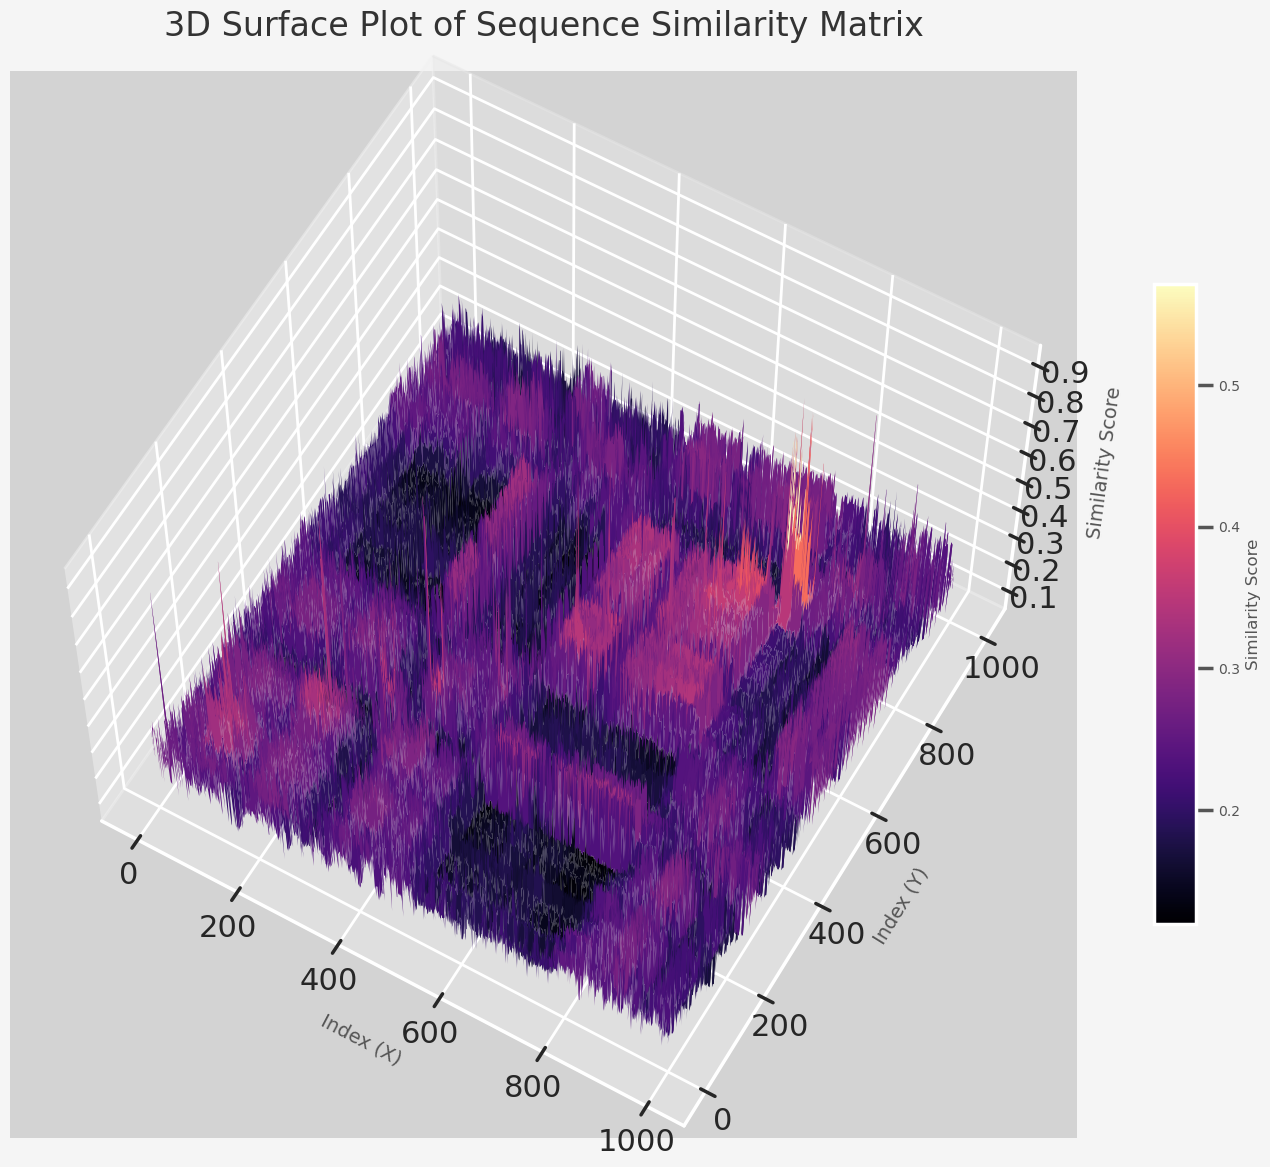

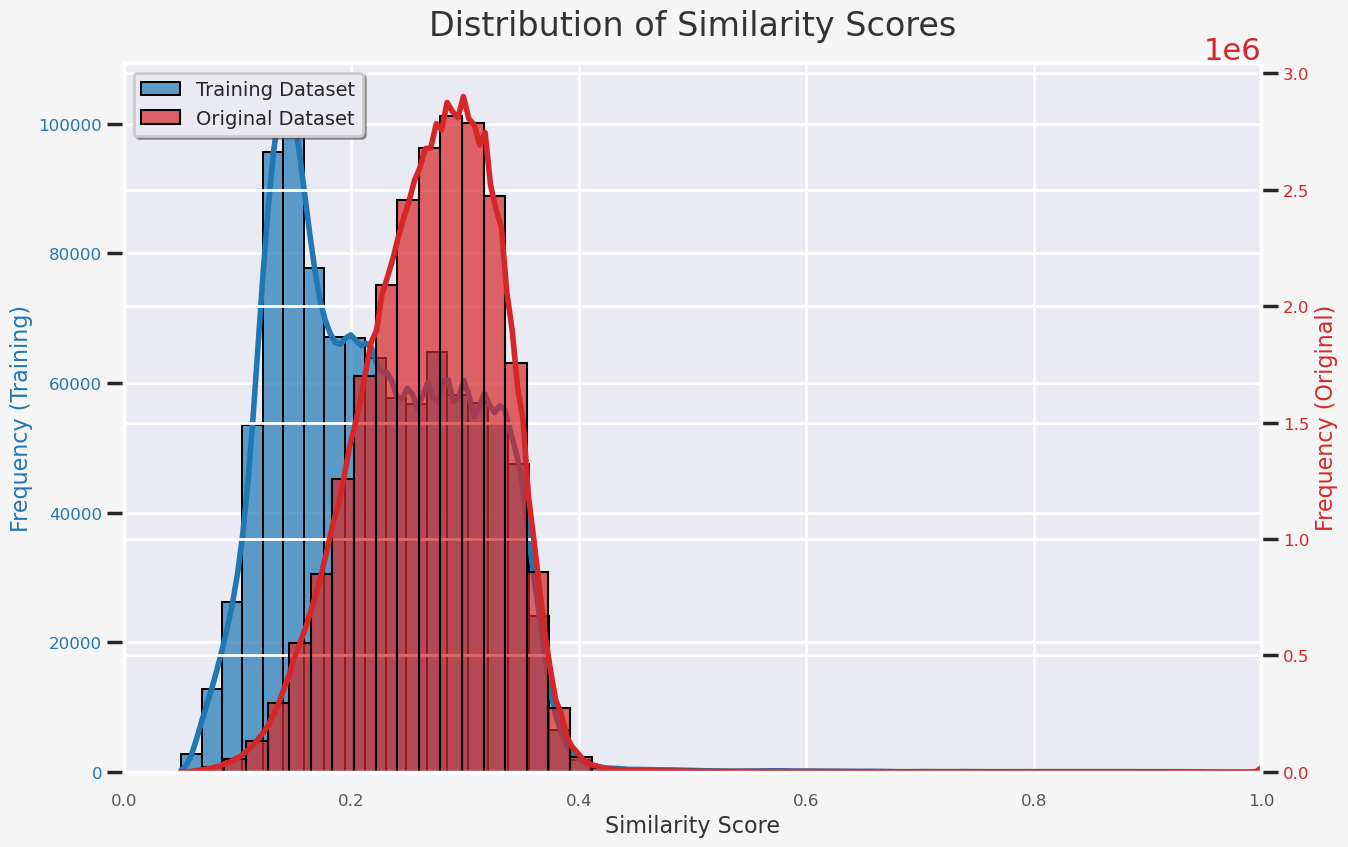

In [52]:
# The Axes3D import is necessary for the '3d' projection, even if not explicitly used.
from mpl_toolkits.mplot3d import Axes3D

def visualize_similarity_matrices(similarity_matrix_training, similarity_matrix_original):
    """
    Generates, visualizes, and saves two similarity matrices plots with enhanced aesthetics.

    This function creates two plots and saves them as PNG files:
    1. A 3D surface plot of a downsampled version of the training similarity matrix
       with a vibrant color scheme.
    2. A histogram showing the distribution of scores for both matrices,
       each with its own Y-axis and a visually striking color palette.
    """
    # Exclude the identity similarity (diagonal) from the training matrix
    np.fill_diagonal(similarity_matrix_training, np.nan)

    # --- Plot 1: 3D Surface Plot of Training Similarity Matrix ---
    print("Creating and saving visually popping 3D surface plot...")
    
    sample_rate = 1
    matrix_training_sampled = similarity_matrix_training[::sample_rate, ::sample_rate]
    
    X, Y = np.meshgrid(
        np.arange(matrix_training_sampled.shape[1]), 
        np.arange(matrix_training_sampled.shape[0])
    )

    fig_3d = plt.figure(figsize=(16, 12))
    ax_3d = fig_3d.add_subplot(111, projection='3d')

    # Use a more vibrant colormap like 'magma'
    surface = ax_3d.plot_surface(
        X, Y, matrix_training_sampled, 
        cmap='magma', 
        edgecolor='none', 
        antialiased=True
    )

    ax_3d.set_title('3D Surface Plot of Sequence Similarity Matrix', fontsize=24, color='#333333', pad=25)
    ax_3d.set_xlabel(' Index (X)', fontsize=14, labelpad=15, color='#555555')
    ax_3d.set_ylabel(' Index (Y)', fontsize=14, labelpad=15, color='#555555')
    ax_3d.set_zlabel('Similarity Score', fontsize=14, labelpad=15, color='#555555')
    
    ax_3d.view_init(elev=60, azim=-60)
    ax_3d.grid(True, linestyle='--', alpha=0.6)
    
    # Customize color bar
    cbar = fig_3d.colorbar(surface, shrink=0.6, aspect=15, label='Similarity Score')
    cbar.set_label('Similarity Score', fontsize=12, color='#555555')
    cbar.ax.tick_params(labelsize=10, colors='#555555')
    
    ax_3d.set_facecolor('lightgray')
    fig_3d.patch.set_facecolor('whitesmoke')

    plt.tight_layout()

    # --- EDIT: Save the 3D plot as a PNG file ---
    # We use dpi=300 for high resolution and bbox_inches='tight' to trim whitespace.
    output_filename_3d = '3d_surface_plot.png'
    fig_3d.savefig(output_filename_3d, dpi=300, bbox_inches='tight')
    print(f"3D plot saved as '{output_filename_3d}'")


    # --- Plot 2: Histograms of Similarity Distributions with Separate Y-Axes ---
    print("\nCreating and saving visually popping histograms...")

    valid_scores_training = similarity_matrix_training.flatten()
    valid_scores_training = valid_scores_training[~np.isnan(valid_scores_training)]
    
    valid_scores_original = similarity_matrix_original.flatten()
    valid_scores_original = valid_scores_original[~np.isnan(valid_scores_original)]

    sns.set_style("darkgrid")
    sns.set_context("poster")

    fig_hist, ax1 = plt.subplots(figsize=(14, 9))

    color_training = '#1f77b4'
    color_original = '#d62728'

    # Plot histogram for the training dataset on the left Y-axis (ax1)
    sns.histplot(
        valid_scores_training,
        bins=50,
        kde=True,
        ax=ax1,
        label="Training Dataset",
        color=color_training,
        alpha=0.7,
        edgecolor='black',
        line_kws={'linewidth': 4, 'color': color_training}
    )
    ax1.set_xlabel('Similarity Score', fontsize=16, color='#333333')
    ax1.set_ylabel('Frequency (Training)', color=color_training, fontsize=16)
    ax1.tick_params(axis='y', labelcolor=color_training, labelsize=12)
    ax1.tick_params(axis='x', labelsize=12, colors='#555555')
    ax1.set_xlim(0, 1)

    # Create a second Y-axis for the original dataset
    ax2 = ax1.twinx() 
    sns.histplot(
        valid_scores_original,
        bins=50,
        kde=True,
        ax=ax2,
        label="Original Dataset",
        color=color_original,
        alpha=0.7,
        edgecolor='black',
        line_kws={'linewidth': 4, 'color': color_original}
    )
    ax2.set_ylabel('Frequency (Original)', color=color_original, fontsize=16)
    ax2.tick_params(axis='y', labelcolor=color_original, labelsize=12)

    plt.title('Distribution of Similarity Scores', fontsize=24, color='#333333', pad=20)
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=14, frameon=True, shadow=True, fancybox=True)

    fig_hist.patch.set_facecolor('whitesmoke')

    plt.tight_layout()

    # --- EDIT: Save the histogram plot as a PNG file ---
    output_filename_hist = 'histograms_plot.png'
    fig_hist.savefig(output_filename_hist, dpi=300, bbox_inches='tight')
    print(f"Histogram plot saved as '{output_filename_hist}'")

    print("\nPlots are saved. Displaying now.")
    plt.show()

if __name__ == '__main__':
    visualize_similarity_matrices(subsim_matrix, similarity_matrix)

# PART 3: DOWNLOAD PDBS

In [11]:
selected_sequences = [sequences[i] for i in selected]
#selected_protein_ids = astral.set_index("sequence").loc[selected_sequences, "protein_id"].to_list()

In [12]:
#load in SCOPe data to get pdb_id information

path = "SCOPe/scope-cla.txt"  # change this to your file

scope_cla = pd.read_csv(
    path,
    sep=r"\s+",
    header=None,
    comment="#",
    engine="python",
    names=["protein_id", "pdb", "chain", "sccs", "col5", "col6"]
)
scope_cla = scope_cla[["protein_id","pdb"]]

astral["protein_id"] = astral["protein_id"].str.replace(r"[>_]", "", regex=True)
scope_cla["protein_id"] = scope_cla["protein_id"].str.replace(r"[>_]", "", regex=True)

scope = pd.merge(astral,scope_cla,on="protein_id",how="left")
selected_scope = scope.loc[selected]

In [13]:
if os.path.exists(cache_file):
    selected_scope = pd.read_csv(cache_file, index_col=0)
    print("READ FROM SELECTED_SCOPE.CSV")
else:
    selected_scope = scope.loc[selected]
    selected_scope.to_csv(cache_file)
    print("SAVED SELECTED_SCOPE.CSV")

selected_scope

NameError: name 'cache_file' is not defined

In [14]:
def setup_logging():
    """Set up logging to both console and file"""
    log_filename = f"pdb_processing_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
    
    # Create logger
    logger = logging.getLogger('pdb_processor')
    logger.setLevel(logging.INFO)
    
    # Clear existing handlers
    if logger.hasHandlers():
        logger.handlers.clear()
    
    # Create file handler
    file_handler = logging.FileHandler(log_filename)
    file_handler.setLevel(logging.INFO)
    
    # Create console handler
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    
    # Create formatter
    formatter = logging.Formatter('%(asctime)s - %(message)s')
    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)
    
    # Add handlers to logger
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    
    return logger

def setup_prody_temp_dir(temp_dir="/scratch/midway2/okleinmann/tmp/"):
    """Set up prody to download PDB files to a specific temp directory"""
    # Create the temp directory if it doesn't exist
    os.makedirs(temp_dir, exist_ok=True)
    
    # Set prody's PDB folder
    pr.pathPDBFolder(temp_dir)
    
    print(f"📁 PDB download directory set to: {temp_dir}")
    
    # Return the string path we know we set
    return temp_dir

def find_terminal_matches(target_seq, pdb_seq, n_term_len=5, c_term_len=5):
    """
    Find N and C terminal matches and return the trimming positions
    """
    if len(target_seq) < n_term_len + c_term_len:
        return None, None, "Sequence too short for terminal matching"
    
    n_term_target = target_seq[:n_term_len]
    c_term_target = target_seq[-c_term_len:]
    
    # Find N-terminal match
    n_match_pos = pdb_seq.find(n_term_target)
    if n_match_pos == -1:
        return None, None, f"N-terminal '{n_term_target}' not found in PDB"
    
    # Find C-terminal match (look for the last occurrence)
    c_match_pos = pdb_seq.rfind(c_term_target)
    if c_match_pos == -1:
        return None, None, f"C-terminal '{c_term_target}' not found in PDB"
    
    # Make sure C-terminal match comes after N-terminal match
    if c_match_pos <= n_match_pos:
        return None, None, "C-terminal match comes before N-terminal match"
    
    # Calculate the extracted region
    start_pos = n_match_pos
    end_pos = c_match_pos + c_term_len
    
    extracted_seq = pdb_seq[start_pos:end_pos]
    
    return start_pos, end_pos, f"N-term '{n_term_target}' at {n_match_pos}, C-term '{c_term_target}' at {c_match_pos}, extracted length: {len(extracted_seq)}"

def download_and_filter_pdb(pdb_id, target_sequence, logger, temp_dir_path, n_term_len=5, c_term_len=5, progress_bar=None):
    """
    Download PDB and filter to target sequence using terminal matching.
    """
    # Update progress bar description
    if progress_bar:
        progress_bar.set_description(f"Processing {pdb_id}")
    
    # Handle NaN/None sequences
    if target_sequence is None or str(target_sequence).lower() == 'nan':
        logger.info(f"Skipping {pdb_id}: No sequence provided (NaN/None)")
        if progress_bar:
            progress_bar.set_postfix(status="SKIPPED: No sequence")
        return "skipped"
    
    # Convert to string and clean
    try:
        target_sequence = str(target_sequence).upper().strip()
    except Exception as e:
        logger.error(f"Error processing sequence for {pdb_id}: {e}")
        if progress_bar:
            progress_bar.set_postfix(status="ERROR: Bad sequence")
        return "error"
    
    if not target_sequence or len(target_sequence) < n_term_len + c_term_len:
        logger.info(f"Skipping {pdb_id}: Sequence too short for terminal matching")
        if progress_bar:
            progress_bar.set_postfix(status="SKIPPED: Too short")
        return "skipped"
    
    # Create pdb directory for final output
    pdb_dir = "pdb"
    os.makedirs(pdb_dir, exist_ok=True)
    
    # Download and parse (will go to temp directory)
    if progress_bar:
        progress_bar.set_postfix(status="Downloading...")
    
    logger.info(f"Downloading and parsing {pdb_id}...")
    logger.info(f"Downloading to temp dir: {temp_dir_path}")
    
    structure = pr.parsePDB(pdb_id)
    
    if structure is None:
        logger.error(f"Failed to download {pdb_id}")
        if progress_bar:
            progress_bar.set_postfix(status="ERROR: Download failed")
        return "error"
    
    # Log where the file was downloaded (check both possible locations)
    possible_files = [
        os.path.join(temp_dir_path, f"{pdb_id.lower()}.pdb.gz"),
        os.path.join(temp_dir_path, f"{pdb_id.upper()}.pdb.gz"),
        os.path.join(temp_dir_path, f"pdb{pdb_id.lower()}.ent.gz")
    ]
    
    for downloaded_file in possible_files:
        if os.path.exists(downloaded_file):
            file_size = os.path.getsize(downloaded_file)
            logger.info(f"Downloaded {pdb_id} to {downloaded_file} ({file_size} bytes)")
            break
    else:
        logger.info(f"Download location not found in expected paths")
    
    if progress_bar:
        progress_bar.set_postfix(status="Parsing sequences...")
    
    logger.info(f"Target sequence: {target_sequence}")
    logger.info(f"Target length: {len(target_sequence)}")
    logger.info(f"Looking for N-term: '{target_sequence[:n_term_len]}' and C-term: '{target_sequence[-c_term_len:]}'")
    
    # Get unique chain IDs
    unique_chains = set(structure.getChids())
    logger.info(f"Available chains: {sorted(unique_chains)}")
    
    # Try each unique chain
    for chain_num, chain_id in enumerate(sorted(unique_chains)):
        if progress_bar:
            progress_bar.set_postfix(status=f"Checking chain {chain_id} ({chain_num+1}/{len(unique_chains)})")
        
        # Select ONLY alpha carbons to get one atom per residue
        chain_ca = structure.select(f'chain {chain_id} and name CA')
        if chain_ca is None or len(chain_ca) == 0:
            logger.info(f"Chain {chain_id}: No CA atoms found")
            continue
        
        # Get sequence from CA atoms
        try:
            resnames = chain_ca.getResnames()
            
            # Standard amino acid conversion
            aa_dict = {
                'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',
                'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',
                'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',
                'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'
            }
            
            sequence = ""
            for resname in resnames:
                if resname in aa_dict:
                    sequence += aa_dict[resname]
                else:
                    sequence += 'X'  # Unknown residue
                    
        except Exception as e:
            logger.error(f"Error extracting sequence from chain {chain_id}: {e}")
            continue
        
        logger.info(f"Chain {chain_id}: {sequence}")
        logger.info(f"Chain {chain_id} length: {len(sequence)}")
        
        if progress_bar:
            progress_bar.set_postfix(status=f"Matching chain {chain_id}...")
        
        # Try terminal matching
        start_pos, end_pos, match_info = find_terminal_matches(target_sequence, sequence, n_term_len, c_term_len)
        
        if start_pos is not None and end_pos is not None:
            if progress_bar:
                progress_bar.set_postfix(status="MATCH! Saving...")
            
            logger.info(f"✓ TERMINAL MATCH found in chain {chain_id}")
            logger.info(f"  {match_info}")
            
            # Get the residue numbers for the matching region
            resnums = chain_ca.getResnums()
            start_resnum = resnums[start_pos]
            end_resnum = resnums[end_pos - 1]  # end_pos is exclusive
            
            logger.info(f"  Extracting residues {start_resnum} to {end_resnum}")
            
            # Extract the matching region from the full structure
            filtered = structure.select(f'chain {chain_id} and resnum {start_resnum}:{end_resnum}')
            
            if filtered is not None:
                # Save the filtered structure to the final pdb directory
                output_path = os.path.join(pdb_dir, f"{pdb_id.lower()}.pdb")
                pr.writePDB(output_path, filtered)
                logger.info(f"✓ Saved filtered structure to {output_path}")
                
                # Verify the file was created
                if os.path.exists(output_path):
                    size = os.path.getsize(output_path)
                    logger.info(f"✓ File saved successfully: {size} bytes")
                    
                    # Log what we extracted
                    extracted_seq = sequence[start_pos:end_pos]
                    logger.info(f"  Extracted sequence: {extracted_seq}")
                    
                    if progress_bar:
                        progress_bar.set_postfix(status="SUCCESS")
                    
                    return "success"
                else:
                    logger.error("❌ File was not created!")
                    if progress_bar:
                        progress_bar.set_postfix(status="ERROR: Save failed")
                    return "error"
            else:
                logger.error("❌ Failed to extract the matching region")
                if progress_bar:
                    progress_bar.set_postfix(status="ERROR: Extract failed")
        else:
            logger.info(f"Chain {chain_id}: {match_info}")
    
    logger.warning("❌ No terminal matches found in any chain!")
    if progress_bar:
        progress_bar.set_postfix(status="NO MATCH")
    
    # Save the full structure for inspection (to final pdb directory)
    output_path = os.path.join(pdb_dir, f"{pdb_id.lower()}_full.pdb")
    pr.writePDB(output_path, structure)
    logger.info(f"Saved full structure to {output_path} for inspection")
    
    return "no_match"

# Set up prody temp directory FIRST
temp_dir = setup_prody_temp_dir("/scratch/midway2/okleinmann/tmp/")

# Set up logging
logger = setup_logging()

# Initialize counters
total_entries = len(selected_scope)
success_count = 0
error_count = 0
skipped_count = 0
no_match_count = 0
already_exists_count = 0

print(f"\n🧬 Starting PDB processing for {total_entries} entries...")
print(f"📥 Raw PDB files will be downloaded to: {temp_dir}")
print(f"📤 Processed PDB files will be saved to: pdb/")
print("="*60)

# Create pdb directory for final output
pdb_dir = "pdb"
os.makedirs(pdb_dir, exist_ok=True)

# Create progress bar
with tqdm(total=total_entries, desc="Overall Progress", ncols=100) as pbar:
    
    # Process your dataframe
    for i in range(total_entries):
        try:
            pdb_id = selected_scope.iloc[i]["pdb"]
            sequence = selected_scope.iloc[i]["sequence"]
            
            # Check if PDB file already exists in the output directory
            output_file = os.path.join(pdb_dir, f"{pdb_id.lower()}.pdb")
            full_output_file = os.path.join(pdb_dir, f"{pdb_id.lower()}_full.pdb")
            
            if os.path.exists(output_file) or os.path.exists(full_output_file):
                already_exists_count += 1
                logger.info(f"Skipping {pdb_id}: File already exists in pdb directory")
                pbar.update(1)
                pbar.set_postfix({
                    'Success': success_count,
                    'No Match': no_match_count, 
                    'Errors': error_count,
                    'Skipped': skipped_count,
                    'Already Exists': already_exists_count
                })
                continue
            
            logger.info(f"\n{'='*80}")
            logger.info(f"Processing {i+1}/{total_entries}: {pdb_id}")
            logger.info(f"{'='*80}")
            
            # Process with progress updates - pass temp_dir as a string
            result = download_and_filter_pdb(pdb_id, sequence, logger, temp_dir, n_term_len=5, c_term_len=5, progress_bar=pbar)
            
            # Update counters
            if result == "success":
                success_count += 1
            elif result == "error":
                error_count += 1
            elif result == "skipped":
                skipped_count += 1
            elif result == "no_match":
                no_match_count += 1
            
            # Update progress bar
            pbar.update(1)
            pbar.set_postfix({
                'Success': success_count,
                'No Match': no_match_count, 
                'Errors': error_count,
                'Skipped': skipped_count,
                'Already Exists': already_exists_count
            })
            
            # Small delay to see progress updates
            time.sleep(0.1)
            
        except Exception as e:
            error_count += 1
            logger.error(f"Error processing row {i}: {e}")
            pbar.update(1)
            pbar.set_postfix(status="ERROR: Exception")
            continue

print("\n" + "="*60)
print("🎉 PROCESSING COMPLETE!")
print("="*60)
print(f"📊 SUMMARY:")
print(f"   ✅ Successful matches: {success_count}")
print(f"   ❌ No matches found:   {no_match_count}")
print(f"   🚫 Errors:            {error_count}")
print(f"   ⏭️  Skipped:           {skipped_count}")
print(f"   📂 Already exists:    {already_exists_count}")
print(f"   📁 Total processed:   {success_count + no_match_count + error_count + skipped_count + already_exists_count}")
print(f"   📈 Success rate:      {(success_count/(total_entries-already_exists_count))*100:.1f}% (excluding already existing)")
print(f"\n📂 Files locations:")
print(f"   📥 Raw PDB downloads: {temp_dir}")
print(f"   📤 Processed outputs: pdb/")

logger.info("Processing complete!")
logger.info(f"Final summary: {success_count} success, {no_match_count} no match, {error_count} errors, {skipped_count} skipped, {already_exists_count} already existed")

bad = [os.remove(f) for f in glob.glob('pdb/*full*') if os.path.isfile(f)]
print("{} PDB IDs had no RCSB match".format(str(len(bad))))

@> Local PDB folder is set: '/scratch/midway2/okleinmann/tmp'
@> A plain folder structure will be assumed.


📁 PDB download directory set to: /scratch/midway2/okleinmann/tmp/

🧬 Starting PDB processing for 1000 entries...
📥 Raw PDB files will be downloaded to: /scratch/midway2/okleinmann/tmp/
📤 Processed PDB files will be saved to: pdb/


Overall Progress:   0%|                                                    | 0/1000 [00:00<?, ?it/s]

2025-09-04 12:23:43,929 - Skipping 1dlw: File already exists in pdb directory
2025-09-04 12:23:43,930 - Skipping 2bmm: File already exists in pdb directory
2025-09-04 12:23:43,932 - Skipping 1it2: File already exists in pdb directory
2025-09-04 12:23:43,933 - Skipping 5eui: File already exists in pdb directory
2025-09-04 12:23:43,934 - Skipping 4h2l: File already exists in pdb directory
2025-09-04 12:23:43,936 - Skipping 3mkb: File already exists in pdb directory
2025-09-04 12:23:43,937 - Skipping 5ker: File already exists in pdb directory
2025-09-04 12:23:43,939 - Skipping 5d1v: File already exists in pdb directory
2025-09-04 12:23:43,940 - Skipping 2zs0: File already exists in pdb directory
2025-09-04 12:23:43,941 - Skipping 2zs0: File already exists in pdb directory
2025-09-04 12:23:43,942 - Skipping 2zs0: File already exists in pdb directory
2025-09-04 12:23:43,944 - Skipping 2d2m: File already exists in pdb directory
2025-09-04 12:23:43,945 - Skipping 5ziq: File already exists in 


🎉 PROCESSING COMPLETE!
📊 SUMMARY:
   ✅ Successful matches: 0
   ❌ No matches found:   37
   🚫 Errors:            10
   ⏭️  Skipped:           9
   📂 Already exists:    944
   📁 Total processed:   1000
   📈 Success rate:      0.0% (excluding already existing)

📂 Files locations:
   📥 Raw PDB downloads: /scratch/midway2/okleinmann/tmp/
   📤 Processed outputs: pdb/
37 PDB IDs had no RCSB match


# PART 4: TAILORING TRAINING SET

In [5]:
# Set the PDB directory path
PDB_DIR = "pdb"  # Change this to your actual PDB directory path

# Initialize the PDB parser
parser = PDBParser(QUIET=True)

In [16]:
def get_n_terminus_distance(structure):
    """
    Calculate distance between successive N-terminus atoms in different chains.
    Returns the minimum distance found between N-terminus atoms of different chains.
    """
    parser = PDBParser(QUIET=True)
    
    # Get all chains
    chains = list(structure.get_chains())
    if len(chains) < 2:
        return 0  # No successive chains to compare
    
    n_terminus_coords = []
    
    # Get N-terminus coordinates for each chain
    for chain in chains:
        residues = list(chain.get_residues())
        if residues:
            first_residue = residues[0]
            if 'N' in first_residue:
                n_atom = first_residue['N']
                n_terminus_coords.append(n_atom.get_coord())
    
    if len(n_terminus_coords) < 2:
        return 0
    
    # Calculate minimum distance between successive N-terminus atoms
    min_distance = float('inf')
    for i in range(len(n_terminus_coords) - 1):
        distance = np.linalg.norm(n_terminus_coords[i] - n_terminus_coords[i + 1])
        min_distance = min(min_distance, distance)
    
    return min_distance

def get_total_residues(structure):
    """
    Count total number of residues in the structure.
    """
    total_residues = 0
    for chain in structure.get_chains():
        for residue in chain.get_residues():
            if PDB.is_aa(residue):  # Only count amino acid residues
                total_residues += 1
    return total_residues

def filter_and_delete_pdbs(directory_path, max_distance=2.0, max_residues=300):
    """
    Delete PDB files that meet the deletion criteria.
    
    Parameters:
    - directory_path: Path to directory containing PDB files
    - max_distance: Maximum allowed distance between successive N-terminus domains (Angstroms)
    - max_residues: Maximum allowed total residues
    """
    parser = PDBParser(QUIET=True)
    
    # Find all PDB files
    pdb_files = glob.glob(os.path.join(directory_path, "*.pdb")) + \
                glob.glob(os.path.join(directory_path, "*.PDB"))
    
    deleted_files = []
    kept_files = []
    error_files = []
    
    print(f"Found {len(pdb_files)} PDB files in {directory_path}")
    print("Processing files...")
    
    for pdb_file in pdb_files:
        try:
            # Parse the PDB file
            structure = parser.get_structure('temp', pdb_file)
            
            # Check criteria
            n_distance = get_n_terminus_distance(structure)
            total_residues = get_total_residues(structure)
            
            should_delete = False
            reasons = []
            
            if n_distance > max_distance:
                should_delete = True
                reasons.append(f"N-terminus distance ({n_distance:.2f} Å) > {max_distance} Å")
            
            if total_residues > max_residues:
                should_delete = True
                reasons.append(f"Total residues ({total_residues}) > {max_residues}")
            
            if should_delete:
                os.remove(pdb_file)
                deleted_files.append((os.path.basename(pdb_file), reasons))
                print(f"DELETED: {os.path.basename(pdb_file)} - {'; '.join(reasons)}")
            else:
                kept_files.append(os.path.basename(pdb_file))
                print(f"KEPT: {os.path.basename(pdb_file)} - N-dist: {n_distance:.2f} Å, Residues: {total_residues}")
                
        except Exception as e:
            error_files.append((os.path.basename(pdb_file), str(e)))
            print(f"ERROR: {os.path.basename(pdb_file)} - {str(e)}")
    
    # Summary
    print(f"\n=== SUMMARY ===")
    print(f"Total files processed: {len(pdb_files)}")
    print(f"Files deleted: {len(deleted_files)}")
    print(f"Files kept: {len(kept_files)}")
    print(f"Files with errors: {len(error_files)}")
    
    if deleted_files:
        print(f"\nDeleted files:")
        for filename, reasons in deleted_files:
            print(f"  - {filename}: {'; '.join(reasons)}")
    
    if error_files:
        print(f"\nFiles with errors:")
        for filename, error in error_files:
            print(f"  - {filename}: {error}")

# Usage example:
# Replace 'your_directory_path' with the actual path to your PDB directory
directory_path = "pdb/"

# Run the filtering and deletion
filter_and_delete_pdbs(directory_path, max_distance=2.0, max_residues=300)


Found 899 PDB files in pdb/
Processing files...
KEPT: 1brw.pdb - N-dist: 0.00 Å, Residues: 69
KEPT: 3gqb.pdb - N-dist: 0.00 Å, Residues: 146
DELETED: 3gzs.pdb - Total residues (494) > 300
KEPT: 3kky.pdb - N-dist: 0.00 Å, Residues: 86
KEPT: 7csv.pdb - N-dist: 0.00 Å, Residues: 97
DELETED: 1ya0.pdb - Total residues (457) > 300
DELETED: 1bvp.pdb - Total residues (348) > 300
DELETED: 1rzs.pdb - Total residues (1260) > 300
KEPT: 6hrd.pdb - N-dist: 0.00 Å, Residues: 96
KEPT: 3gws.pdb - N-dist: 0.00 Å, Residues: 246
KEPT: 3fs7.pdb - N-dist: 0.00 Å, Residues: 107
DELETED: 6zhz.pdb - Total residues (335) > 300
DELETED: 4p6z.pdb - Total residues (569) > 300
KEPT: 1z5x.pdb - N-dist: 0.00 Å, Residues: 236
KEPT: 3elo.pdb - N-dist: 0.00 Å, Residues: 72
DELETED: 3zpi.pdb - Total residues (395) > 300
KEPT: 3ay8.pdb - N-dist: 0.00 Å, Residues: 119
KEPT: 2bmm.pdb - N-dist: 0.00 Å, Residues: 122
KEPT: 5wfx.pdb - N-dist: 0.00 Å, Residues: 232
KEPT: 2ffx.pdb - N-dist: 0.00 Å, Residues: 172
DELETED: 3tyw.pd

In [16]:
# Get list of PDB files
pdb_files = [f for f in os.listdir(PDB_DIR) if f.endswith('.pdb')]
print(f"Found {len(pdb_files)} PDB files")

# Process all PDB files
pdb_data = []

for pdb_file in pdb_files:
    pdb_path = os.path.join(PDB_DIR, pdb_file)
    info = get_pdb_info(pdb_path)
    
    if info is not None:
        # Add the strict chain break check with 2 Angstrom threshold
        info['chain_break_2A'] = check_chain_breaks_strict(pdb_path, threshold=2.0)
        pdb_data.append(info)

# Create DataFrame
df = pd.DataFrame(pdb_data)
print(f"Successfully processed {len(df)} PDB files")
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
df.head()

Found 603 PDB files


NameError: name 'get_pdb_info' is not defined

In [175]:
# Initial dataset size
print(f"Initial dataset size: {len(df)} PDBs")

# Filter 1: Remove PDBs with chain breaks (using 2 Angstrom threshold)
df_filtered = df[~df['chain_break_2A']].copy()
print(f"After removing chain breaks (>2Å): {len(df_filtered)} PDBs remaining")
print(f"Removed: {len(df) - len(df_filtered)} PDBs with chain breaks")

# Filter 2: Remove PDBs over 300 residues
df_filtered = df_filtered[df_filtered['length'] <= 300].copy()
print(f"After removing PDBs >300 residues: {len(df_filtered)} PDBs remaining")

# Display summary statistics
print("\nSummary statistics for filtered dataset:")
print(df_filtered[['length', 'atom_count']].describe())

# Show length distribution
print(f"\nLength distribution:")
print(f"Min length: {df_filtered['length'].min()}")
print(f"Max length: {df_filtered['length'].max()}")
print(f"Mean length: {df_filtered['length'].mean():.1f}")
print(f"Median length: {df_filtered['length'].median():.1f}")

Initial dataset size: 899 PDBs
After removing chain breaks (>2Å): 0 PDBs remaining
Removed: 899 PDBs with chain breaks
After removing PDBs >300 residues: 0 PDBs remaining

Summary statistics for filtered dataset:
       length  atom_count
count     0.0         0.0
mean      NaN         NaN
std       NaN         NaN
min       NaN         NaN
25%       NaN         NaN
50%       NaN         NaN
75%       NaN         NaN
max       NaN         NaN

Length distribution:
Min length: nan
Max length: nan
Mean length: nan
Median length: nan


Loading PDB files and calculating residue lengths...
Loaded 603 valid PDB files
Training set: 482 files
Validation set: 121 files
Moving files to train/validation directories...


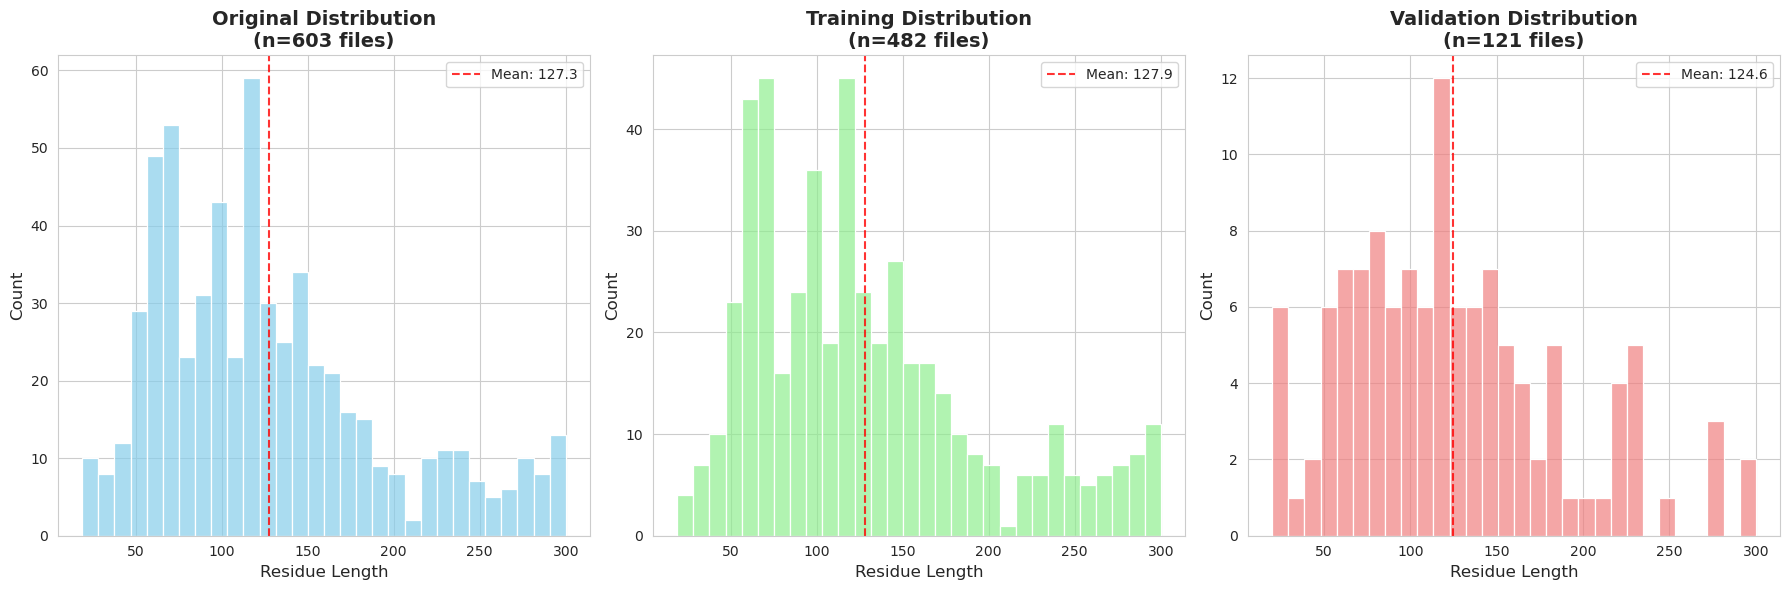


SUMMARY STATISTICS
       Original  Training  Validation
count    603.00    482.00      121.00
mean     127.28    127.94      124.64
std       66.33     67.11       63.35
min       19.00     19.00       20.00
25%       73.00     72.00       81.00
50%      117.00    117.00      119.00
75%      160.00    160.75      159.00
max      300.00    300.00      300.00


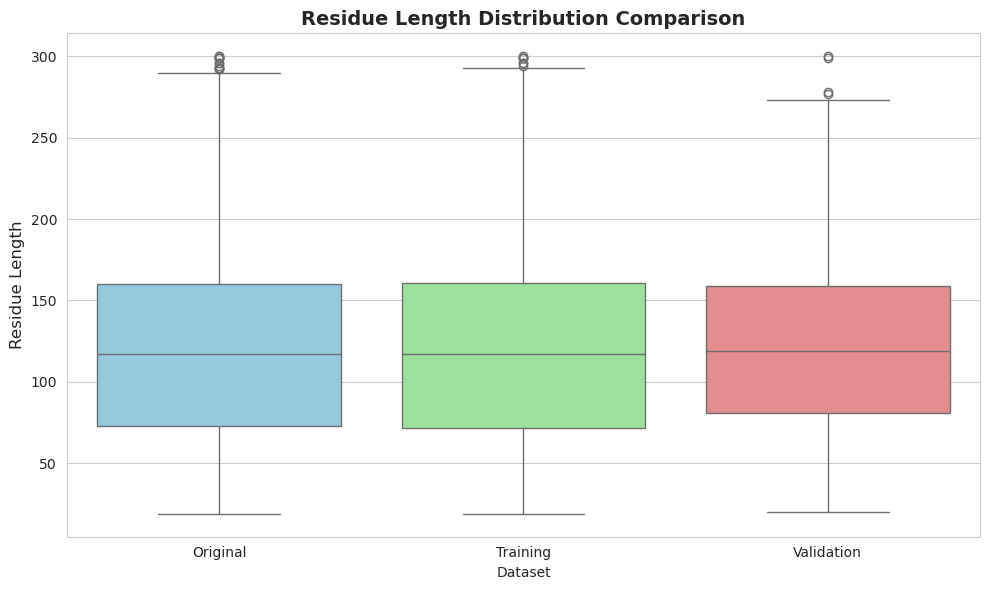


Files successfully split and moved to:
  Training: PDB_train/
  Validation: PDB_validation/


In [18]:
# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

def get_pdb_residue_length(pdb_path):
    """Extract the number of residues from a PDB file"""
    try:
        residues = set()
        with open(pdb_path, 'r') as f:
            for line in f:
                if line.startswith('ATOM'):
                    chain_id = line[21]
                    res_num = line[22:26].strip()
                    residues.add((chain_id, res_num))
        return len(residues)
    except:
        return 0

# Define directories
pdb_dir = "pdb/"  # Change this to your PDB directory path
train_dir = "PDB_train/"
val_dir = "PDB_validation/"

# Create output directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Load all PDB files and get their residue lengths
print("Loading PDB files and calculating residue lengths...")
pdb_files = glob.glob(os.path.join(pdb_dir, "*.pdb"))
pdb_data = []

for pdb_file in pdb_files:
    filename = os.path.basename(pdb_file)
    residue_length = get_pdb_residue_length(pdb_file)
    if residue_length > 0:  # Only include valid PDB files
        pdb_data.append({
            'filename': filename,
            'filepath': pdb_file,
            'residue_length': residue_length
        })

df = pd.DataFrame(pdb_data)
print(f"Loaded {len(df)} valid PDB files")

if len(df) == 0:
    print("No valid PDB files found!")
else:
    # Create length bins for stratified splitting
    df['length_bin'] = pd.qcut(df['residue_length'], q=5, labels=['very_short', 'short', 'medium', 'long', 'very_long'])
    
    # Split the data using stratified sampling based on length bins
    train_df, val_df = train_test_split(
        df, 
        test_size=0.2, 
        random_state=42, 
        stratify=df['length_bin']
    )
    
    print(f"Training set: {len(train_df)} files")
    print(f"Validation set: {len(val_df)} files")
    
    # Move files to respective directories
    print("Moving files to train/validation directories...")
    for _, row in train_df.iterrows():
        shutil.copy2(row['filepath'], os.path.join(train_dir, row['filename']))
    
    for _, row in val_df.iterrows():
        shutil.copy2(row['filepath'], os.path.join(val_dir, row['filename']))
    
    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # (a) Original distribution
    sns.histplot(data=df, x='residue_length', bins=30, ax=axes[0], color='skyblue', alpha=0.7)
    axes[0].set_title(f'Original Distribution\n(n={len(df)} files)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Residue Length', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].axvline(df['residue_length'].mean(), color='red', linestyle='--', alpha=0.8, label=f'Mean: {df["residue_length"].mean():.1f}')
    axes[0].legend()
    
    # (b) Training distribution
    sns.histplot(data=train_df, x='residue_length', bins=30, ax=axes[1], color='lightgreen', alpha=0.7)
    axes[1].set_title(f'Training Distribution\n(n={len(train_df)} files)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Residue Length', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].axvline(train_df['residue_length'].mean(), color='red', linestyle='--', alpha=0.8, label=f'Mean: {train_df["residue_length"].mean():.1f}')
    axes[1].legend()
    
    # (c) Validation distribution
    sns.histplot(data=val_df, x='residue_length', bins=30, ax=axes[2], color='lightcoral', alpha=0.7)
    axes[2].set_title(f'Validation Distribution\n(n={len(val_df)} files)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Residue Length', fontsize=12)
    axes[2].set_ylabel('Count', fontsize=12)
    axes[2].axvline(val_df['residue_length'].mean(), color='red', linestyle='--', alpha=0.8, label=f'Mean: {val_df["residue_length"].mean():.1f}')
    axes[2].legend()
    
    plt.tight_layout()
    # Save the first plot
    plt.savefig('distribution_comparison_hist.png', dpi=300)
    plt.show()
    
    # Additional summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    summary_stats = pd.DataFrame({
        'Original': df['residue_length'].describe(),
        'Training': train_df['residue_length'].describe(),
        'Validation': val_df['residue_length'].describe()
    }).round(2)
    
    print(summary_stats)
    
    # Alternative visualization: Box plots for comparison
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Prepare data for box plot
    plot_data = []
    for dataset, label in [(df, 'Original'), (train_df, 'Training'), (val_df, 'Validation')]:
        for length in dataset['residue_length']:
            plot_data.append({'Dataset': label, 'Residue Length': length})
    
    plot_df = pd.DataFrame(plot_data)
    
    sns.boxplot(data=plot_df, x='Dataset', y='Residue Length', ax=ax, palette=['skyblue', 'lightgreen', 'lightcoral'])
    ax.set_title('Residue Length Distribution Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Residue Length', fontsize=12)
    
    plt.tight_layout()
    # Save the second plot
    plt.savefig('distribution_comparison_boxplot.png', dpi=300)
    plt.show()
    
    print(f"\nFiles successfully split and moved to:")
    print(f"  Training: {train_dir}")
    print(f"  Validation: {val_dir}")